# 🛠️ Required Libraries

In [ ]:
# 📦 Core Libraries
import os
import datetime

# 📊 Data Handling
import pandas as pd

# 🎨 Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


### 📊 Data Loading, Processing, and Plotting

In [ ]:
def set_cm_text_style(prefer_tex=True):
    '''
    Set matplotlib text style to Computer Modern (LaTeX) or fallback serif.
    
    Parameters
    ----------
    prefer_tex : bool, optional
        If True, enable LaTeX rendering; otherwise use built-in serif fonts.
    '''
    if prefer_tex:
        plt.rcParams.update({
            "text.usetex": True,
            "font.family": "serif",
            "font.serif": ["Computer Modern Roman"],
            "axes.unicode_minus": False,
            "pgf.preamble": r"\usepackage{amsmath}\usepackage{bm}",
        })
    else:
        plt.rcParams.update({
            "text.usetex": False,
            "font.family": "serif",
            "font.serif": ["DejaVu Serif"],
            "mathtext.fontset": "cm",
            "mathtext.rm": "serif",
            "mathtext.it": "serif:italic",
            "mathtext.bf": "serif:bold",
            "axes.unicode_minus": False,
        })


def load_simulation_data(N, C, attack_mode="hub1-hub1", drop_node=True):
    '''
    Load CSVs for (N, C, attack_mode), return list of DataFrames.
    Optionally drop node columns.
    '''
    data_dir = f'./data/N{N}/{attack_mode}/C{C}/'
    dfs = []

    if not os.path.exists(data_dir):
        print(f"[WARNING] Directory not found: {data_dir}")
        return []

    for file_name in os.listdir(data_dir):
        if not file_name.endswith(".csv"):
            continue
        try:
            df = pd.read_csv(
                os.path.join(data_dir, file_name),
                sep=r"\s+",
                header=None,
                names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"],
                engine="python",
            )
            if drop_node:
                df.drop(['node1', 'node2'], axis=1, inplace=True)
            dfs.append(df)
        except Exception as e:
            print(f"[ERROR] Failed to read {file_name}: {e}")

    return dfs


def compute_average_curves(N, C, attack_mode="random"):
    '''
    Compute mean and std curves for given (N, C, attack_mode).
    '''
    dfs = load_simulation_data(N, C, attack_mode=attack_mode)
    if not dfs:
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    mean_df = combined.groupby("p", as_index=False).mean(numeric_only=True)
    std_df  = combined.groupby("p", as_index=False).std(numeric_only=True)
    return pd.merge(mean_df, std_df, on="p", suffixes=("", "_std"))


def plot_m1_single_N_all_C_means(N, attack_mode="hub1-hub1",
                                 prefer_tex=True, fill_std=True,
                                 save_with_timestamp=True):
    '''
    Plot m1 mean curves for all C ∈ {1,2,3,N} in one figure.
    '''
    set_cm_text_style(prefer_tex=prefer_tex)

    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    ax.set_axisbelow(True)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    C_values = [1, 2, 3, N]
    labels = {1: r"$C=1$", 2: r"$C=2$", 3: r"$C=3$", N: r"$C=N$"}
    markers = ["o", "s", "D", "^"]

    any_plotted = False
    for idx, C in enumerate(C_values):
        df = compute_average_curves(N, C, attack_mode=attack_mode)
        if df.empty or "p" not in df or "m1" not in df:
            print(f"[WARNING] No data for N={N}, C={C}, mode={attack_mode}.")
            continue

        ax.plot(df["p"], df["m1"],
                marker=markers[idx % len(markers)], linewidth=1.5, markersize=2.0,
                label=labels[C])

        if fill_std and "m1_std" in df.columns and not df["m1_std"].isna().all():
            m, s = df["m1"].to_numpy(), df["m1_std"].fillna(0).to_numpy()
            ax.fill_between(df["p"], m - s, m + s, alpha=0.18, linewidth=0)

        any_plotted = True

    if not any_plotted:
        print("[ERROR] No curves plotted (missing data).")
        return

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"$p$", fontsize=18)
    ax.set_ylabel(r"$N_{G}/N$", fontsize=18)
    ax.tick_params(labelsize=14, direction='in')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: '' if v == 0 else f'{v:g}'))

    ax.legend(fontsize=13, frameon=True, fancybox=True, edgecolor='black', loc='best')
    ax.set_title(rf"$N={N}$ — {attack_mode}", fontsize=14)
    ax.grid(False)

    fig.tight_layout()

    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out = f"attack_{attack_mode}_N{N}_means_{ts}.png" if save_with_timestamp \
          else f"attack_{attack_mode}_N{N}_means.png"

    fig.savefig(out, dpi=300, bbox_inches='tight', transparent=True)
    print(f"[OK] Figure saved at: {out}")
    plt.show()


### 📈 Plot for $N=1500$, mode $hub–hub$

[OK] Figure saved at: attack_random1-random2_N1500_means.png


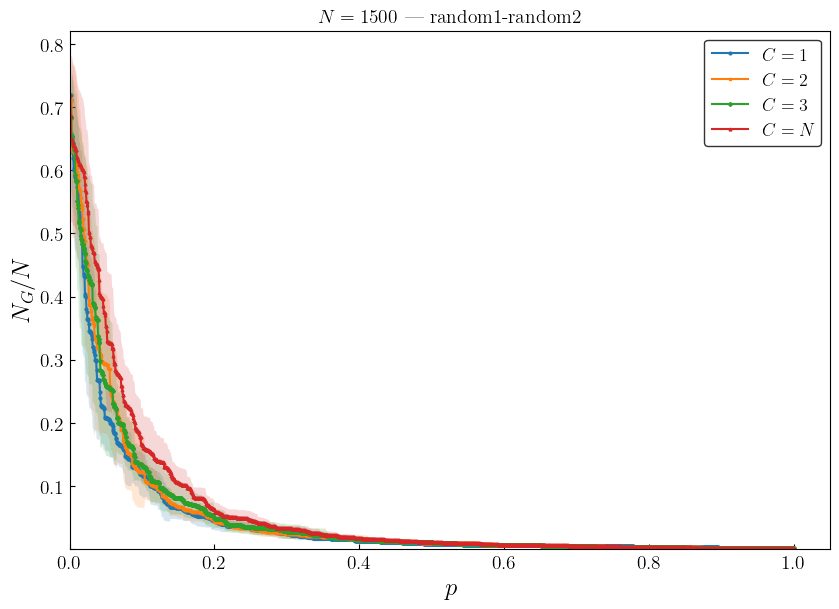

In [32]:
plot_m1_single_N_all_C_means(
    N=1500,
    attack_mode="random1-random2",
    prefer_tex=True,      
    fill_std=True,    
    save_with_timestamp=False)

### 📈 Plot for $N=1500$, mode $hub–random$

[OK] Figure saved at: attack_hub1-random2_N1500_means.png


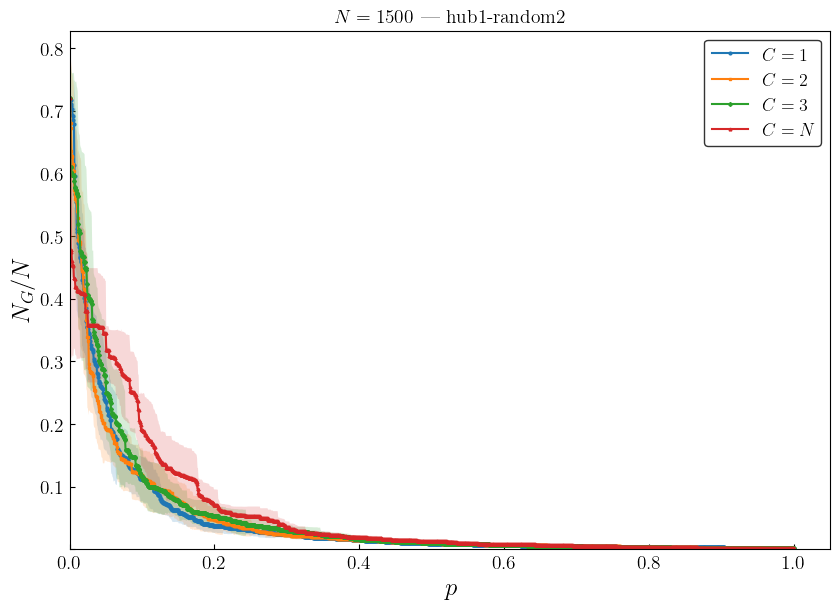

In [24]:
plot_m1_single_N_all_C_means(
    N=1500,
    attack_mode="hub1-random2",
    prefer_tex=True,      
    fill_std=True,    
    save_with_timestamp=False)

### 📈 Plot for $N=1500$, mode $betweenness–betweenness$

[OK] Figure saved at: attack_betweenness1-betweenness2_N1500_means.png


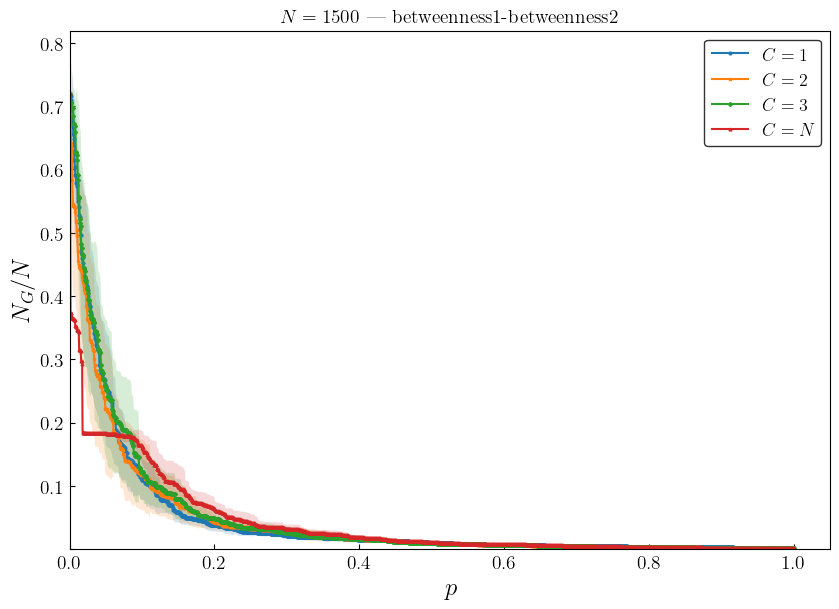

In [31]:
plot_m1_single_N_all_C_means(
    N=1500,
    attack_mode="betweenness1-betweenness2",
    prefer_tex=True,      
    fill_std=True,    
    save_with_timestamp=False)

### 📈 Plot for $N=1500$, mode $closeness–closeness$

[OK] Figure saved at: attack_closeness1-closeness2_N1500_means.png


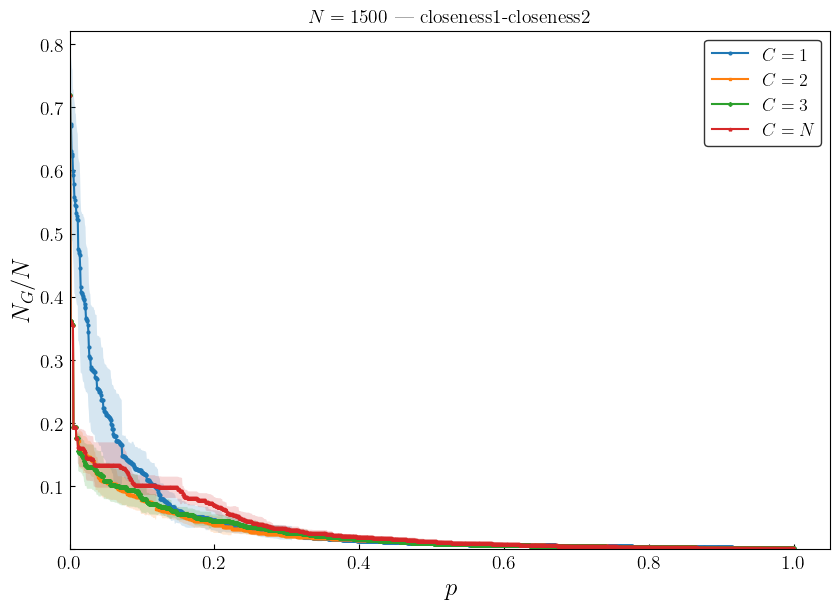

In [30]:
plot_m1_single_N_all_C_means(
    N=1500,
    attack_mode="closeness1-closeness2",
    prefer_tex=True,      
    fill_std=True,    
    save_with_timestamp=False)